### Regression **inference** (pooled, full-sample)

Inferential OLS on **weighted (relative-risk) rate** — *coefficients*, not held-out prediction. Design per **ADR 0003 §Update 2026-09-10**:

- **Objective:** explain **within-city** BG crime variation that generalizes across cities.
- **Two targets** per weighted category (resident-pop denominator):
  - **`log(weighted rate)`** — absolute level, **paired with pooled/raw predictors**.
  - **per-city z-score of `log(weighted rate)`** — the within-city "risk index", **paired
    with per-city DEMEANED predictors** (the within / fixed-effects estimator; test-time-safe because a city is demeaned by its own observed X, not a learned dummy).
- **Two city sets:** `wprop` (property composite) over **10** POC cities; `wtotal` (total)
  over the **5** full-coverage cities.
- Full-sample fit (no CV here); HC3 robust SEs; residual **Moran's I** + choropleths surface
  leftover spatial / between-city structure. No race/protected predictors enter the model.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from crime_blockgroup_mapping.constants import CITIES
from regression_modelling.models.cv import load_pooled_table, make_target, _demean_predictors
from regression_modelling.models.model import standardize, coef_table, fit_summary, residual_spatial
from regression_modelling.constants import PREDICTOR_COLS

full_cities = [c for c, cfg in CITIES.items() if not cfg.property_only]   # 5 full-coverage
all_cities  = list(CITIES.keys())                                         # 10 POC
print("full (wtotal):", full_cities)
print("all  (wprop): ", all_cities)
print("predictors:", len(PREDICTOR_COLS))

full (wtotal): ['houston', 'chicago', 'atlanta', 'kansas_city', 'detroit']
all  (wprop):  ['houston', 'chicago', 'atlanta', 'sacramento', 'san_francisco', 'pittsburgh', 'kansas_city', 'columbus', 'jacksonville', 'detroit']
predictors: 23


In [2]:
# Pooled BG tables (load_pooled_table drops zero/NaN-pop + small-denominator artifacts).
pool5  = load_pooled_table(full_cities)   # wtotal / 5 full-coverage cities
pool10 = load_pooled_table(all_cities)    # wprop  / 10 POC cities
print("pool5 :", pool5.shape)
print("pool10:", pool10.shape)

  houston            1629 BGs
  chicago            2164 BGs


  atlanta             426 BGs
  kansas_city         473 BGs
  detroit             622 BGs
  pooled             5314 BGs across 5 cities
  dropped 22 zero/NaN-pop BGs -> 5292 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 8 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 5284 remain
  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  sacramento          366 BGs
  san_francisco       679 BGs
  pittsburgh          317 BGs


  kansas_city         473 BGs
  columbus            637 BGs


  jacksonville        550 BGs
  detroit             622 BGs
  pooled             7863 BGs across 10 cities
  dropped 32 zero/NaN-pop BGs -> 7831 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 12 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 7819 remain
pool5 : (5284, 98)
pool10: (7819, 98)


### Target-paired inference helper

`fit_inference` builds the target with `make_target`, applies the paired predictor treatment
(pooled/raw for `lograte`; per-city demeaned for `lograte_within_city`), z-standardizes, and
fits HC3-robust OLS on the **whole** pooled frame. It returns the fitted design frame (with
`geoid`, `city`, residuals) so residual Moran's I / choropleths reuse it.

Note: `coef_table`'s `pct_effect = (exp(coef)-1)*100` is only interpretable for the **log**
target; ignore that column for the z-score fit (coefficients there are SD-of-y per +1 SD-of-X,
already demeaned within city).

In [3]:
def fit_inference(pooled, category, mode, demean, predictors=PREDICTOR_COLS):
    """Full-sample HC3 OLS with target-paired predictor treatment.
    Returns (result, robust, design_frame, predictors)."""
    preds = [p for p in predictors if p in pooled.columns]
    d = pooled.dropna(subset=preds).copy()
    d["_y"] = make_target(d, mode=mode, category=category)
    d = d.dropna(subset=["_y"])
    block = _demean_predictors(d, preds) if demean else d[preds]
    X = sm.add_constant(standardize(block), has_constant="add")
    res = sm.OLS(d["_y"].to_numpy(), X).fit()
    robust = res.get_robustcov_results(cov_type="HC3")
    d = d.assign(_resid=res.resid, _fitted=res.fittedvalues)
    return res, robust, d, preds

def report(res, robust, preds, title):
    print(title); print("=" * len(title))
    print(fit_summary(res).to_string(), "\n")
    print(coef_table(res, robust, preds).to_string())

def moran_table(d, k=6):
    """In-sample residual Moran's I per city (KNN centroid weights)."""
    rows = []
    for c in sorted(d["city"].unique()):
        g = d[d["city"] == c]
        _, mi = residual_spatial(c, g["geoid"].to_numpy(), g["_resid"].to_numpy(), k=k)
        rows.append({"city": c, "n": len(g), "moran_I": round(float(mi.I), 3),
                     "p_sim": round(float(mi.p_sim), 4),
                     "spatial_autocorr": "yes" if mi.p_sim < 0.05 else "no"})
    return pd.DataFrame(rows).set_index("city")

### Total composite (`wtotal`) · 5 full-coverage cities

Target = weighted total (7-crime) relative-risk rate.

In [4]:
# A1 — ABSOLUTE log(wtotal_rate), pooled/raw predictors (the level model)
resA_abs, robA_abs, dA_abs, predsA = fit_inference(pool5, "wtotal", "lograte", demean=False)
report(resA_abs, robA_abs, predsA, "A1 · wtotal · log(rate) · pooled/raw X")

A1 · wtotal · log(rate) · pooled/raw X
n            5014.0000
r2              0.4805
r2_adj          0.4781
f_pvalue        0.0000
aic         12169.6000 

                                  coef      se       p  se_HC3     t_HC3   p_HC3  pct_effect  sig
const                           3.5562  0.0115  0.0000  0.0115  308.7087  0.0000   3403.0982  ***
moved1yr_pct                    0.0162  0.0141  0.2523  0.0162    1.0005  0.3171      1.6330     
own_pct                        -0.2624  0.0171  0.0000  0.0231  -11.3694  0.0000    -23.0832  ***
lap_pct                        -0.0250  0.0196  0.2028  0.0245   -1.0224  0.3066     -2.4692     
city_centers_dist              -0.0966  0.0131  0.0000  0.0163   -5.9356  0.0000     -9.2037  ***
pop_est_5mile_log              -0.1366  0.0148  0.0000  0.0164   -8.3186  0.0000    -12.7664  ***
pop_ch_1mile                   -0.0308  0.0129  0.0167  0.0149   -2.0711  0.0384     -3.0347    *
vacant_pct_log                  0.1205  0.0211  0.0000  0.02

In [5]:
# A2 — WITHIN-CITY z-score of log(wtotal_rate), per-city DEMEANED predictors (within estimator)
resA_wc, robA_wc, dA_wc, _ = fit_inference(pool5, "wtotal", "lograte_within_city", demean=True)
report(resA_wc, robA_wc, predsA, "A2 · wtotal · within-city z · demeaned X")

A2 · wtotal · within-city z · demeaned X
n            5014.0000
r2              0.4528
r2_adj          0.4502
f_pvalue        0.0000
aic         11249.3000 

                                  coef      se       p  se_HC3    t_HC3   p_HC3  pct_effect  sig
const                           0.0000  0.0105  1.0000  0.0105   0.0000  1.0000      0.0000     
moved1yr_pct                    0.0128  0.0127  0.3117  0.0139   0.9225  0.3563      1.2924     
own_pct                        -0.2160  0.0158  0.0000  0.0227  -9.5121  0.0000    -19.4270  ***
lap_pct                        -0.0162  0.0176  0.3569  0.0225  -0.7220  0.4703     -1.6094     
city_centers_dist              -0.0551  0.0124  0.0000  0.0157  -3.5091  0.0005     -5.3622  ***
pop_est_5mile_log              -0.0195  0.0129  0.1301  0.0159  -1.2248  0.2207     -1.9295     
pop_ch_1mile                   -0.0286  0.0115  0.0131  0.0131  -2.1950  0.0282     -2.8239    *
vacant_pct_log                  0.1028  0.0162  0.0000  0.0210   4

### Residual spatial structure (in-sample Moran's I)

Positive & significant Moran's I ⇒ residuals cluster in space ⇒ the (non-spatial) model is
still missing structure ⇒ the case for a spatial control / spatial-lag next iteration.

In [6]:
print("ABSOLUTE (log rate, pooled X):")
mtA_abs = moran_table(dA_abs); print(mtA_abs.to_string())
print("\nWITHIN-CITY (z-score, demeaned X):")
mtA_wc = moran_table(dA_wc);  print(mtA_wc.to_string())

ABSOLUTE (log rate, pooled X):


Atlanta state block groups loaded: 7,441


Atlanta city boundary loaded: 1 row(s)


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 426 / 7,441


...

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 1,629 / 18,626


Kansas City state block groups loaded: 5,031


Kansas City city boundary loaded: 1 row(s)
Block groups within city: 473 / 5,031
                n  moran_I  p_sim spatial_autocorr
city                                              
atlanta       369    0.266  0.001              yes
chicago      2064    0.183  0.001              yes
detroit       600    0.092  0.001              yes
houston      1536    0.213  0.001              yes
kansas_city   445    0.087  0.001              yes


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Atlanta state block groups loaded: 7,441


Atlanta city boundary loaded: 1 row(s)
Block groups within city: 426 / 7,441


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Chicago state block groups loaded: 9,896


Chicago city boundary loaded: 1 row(s)
Block groups within city: 2,164 / 9,896


...

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 1,629 / 18,626


Kansas City state block groups loaded: 5,031


Kansas City city boundary loaded: 1 row(s)
Block groups within city: 473 / 5,031


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


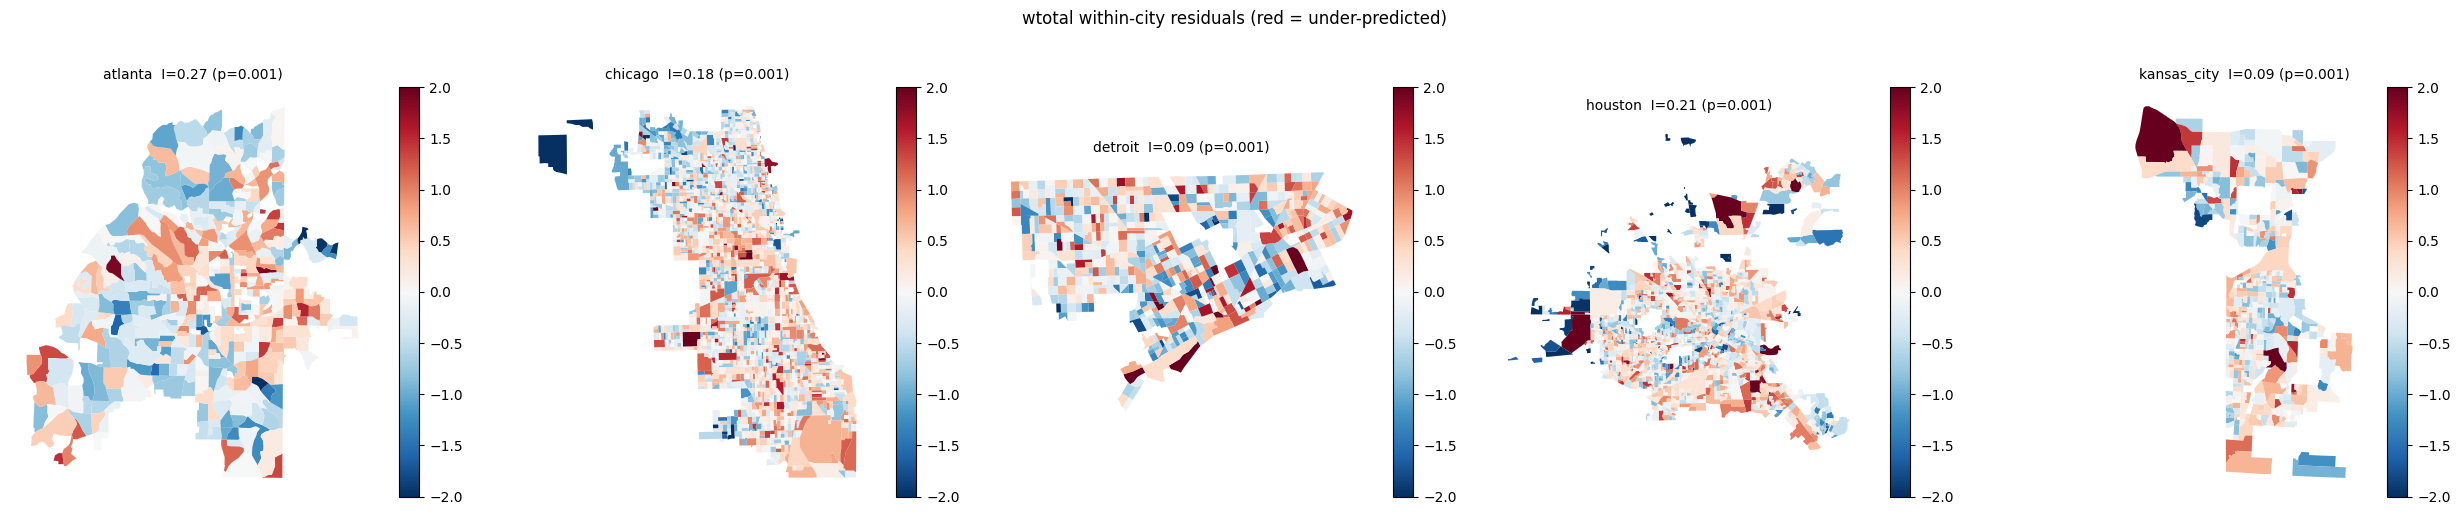

In [7]:
# Residual choropleths — within-city estimator (A2), one panel per city.
fig, axes = plt.subplots(1, len(full_cities), figsize=(5 * len(full_cities), 5))
for ax, c in zip(np.atleast_1d(axes), sorted(full_cities)):
    g = dA_wc[dA_wc["city"] == c]
    gdf, mi = residual_spatial(c, g["geoid"].to_numpy(), g["_resid"].to_numpy(), k=6)
    gdf.plot(column="resid", cmap="RdBu_r", vmin=-2, vmax=2, legend=True,
             ax=ax, edgecolor="none")
    ax.set_title(f"{c}  I={mi.I:.2f} (p={mi.p_sim:.3f})", fontsize=10); ax.axis("off")
fig.suptitle("wtotal within-city residuals (red = under-predicted)", y=1.02)
plt.tight_layout(); plt.show()

### Property composite (`wprop`) · 10 POC cities

Target = weighted property (burglary+larceny+mvt) relative-risk rate. The 5 `property_only`
cities join here because violent-crime coordinates are not required.

In [8]:
# B1 — ABSOLUTE log(wprop_rate), pooled/raw predictors
resB_abs, robB_abs, dB_abs, predsB = fit_inference(pool10, "wprop", "lograte", demean=False)
report(resB_abs, robB_abs, predsB, "B1 · wprop · log(rate) · pooled/raw X")

B1 · wprop · log(rate) · pooled/raw X
n            7437.0000
r2              0.3903
r2_adj          0.3884
f_pvalue        0.0000
aic         17225.9000 

                                  coef      se       p  se_HC3     t_HC3   p_HC3  pct_effect  sig
const                           3.2222  0.0089  0.0000  0.0089  360.3029  0.0000   2408.2649  ***
moved1yr_pct                    0.0318  0.0110  0.0038  0.0148    2.1407  0.0323      3.2286    *
own_pct                        -0.1339  0.0134  0.0000  0.0194   -6.8839  0.0000    -12.5293  ***
lap_pct                         0.0675  0.0149  0.0000  0.0198    3.4189  0.0006      6.9857  ***
city_centers_dist              -0.0617  0.0105  0.0000  0.0132   -4.6584  0.0000     -5.9805  ***
pop_est_5mile_log              -0.0189  0.0119  0.1117  0.0128   -1.4784  0.1393     -1.8719     
pop_ch_1mile                   -0.0140  0.0101  0.1651  0.0117   -1.1915  0.2335     -1.3859     
vacant_pct_log                  0.1497  0.0160  0.0000  0.020

In [9]:
# B2 — WITHIN-CITY z-score of log(wprop_rate), per-city DEMEANED predictors
resB_wc, robB_wc, dB_wc, _ = fit_inference(pool10, "wprop", "lograte_within_city", demean=True)
report(resB_wc, robB_wc, predsB, "B2 · wprop · within-city z · demeaned X")

B2 · wprop · within-city z · demeaned X
n            7437.0000
r2              0.3656
r2_adj          0.3636
f_pvalue        0.0000
aic         17759.0000 



                                  coef      se       p  se_HC3    t_HC3   p_HC3  pct_effect  sig
const                          -0.0000  0.0092  1.0000  0.0093  -0.0000  1.0000      0.0000     
moved1yr_pct                    0.0439  0.0112  0.0001  0.0147   2.9914  0.0028      4.4836   **
own_pct                        -0.1534  0.0141  0.0000  0.0216  -7.1084  0.0000    -14.2224  ***
lap_pct                         0.0250  0.0154  0.1048  0.0212   1.1781  0.2388      2.5349     
city_centers_dist              -0.0376  0.0109  0.0006  0.0138  -2.7257  0.0064     -3.6896   **
pop_est_5mile_log              -0.0401  0.0112  0.0004  0.0133  -3.0040  0.0027     -3.9279   **
pop_ch_1mile                   -0.0401  0.0104  0.0001  0.0117  -3.4407  0.0006     -3.9339  ***
vacant_pct_log                  0.1236  0.0144  0.0000  0.0191   6.4774  0.0000     13.1534  ***
clip_liens_pct_log              0.0261  0.0122  0.0329  0.0163   1.5969  0.1103      2.6433     
clip_foreclosure_pct_log      

In [10]:
# B3 — residual Moran's I per city (10 cities), within-city estimator
print("WITHIN-CITY (z-score, demeaned X), 10 cities:")
mtB_wc = moran_table(dB_wc); print(mtB_wc.to_string())

WITHIN-CITY (z-score, demeaned X), 10 cities:


Atlanta state block groups loaded: 7,441


Atlanta city boundary loaded: 1 row(s)
Block groups within city: 426 / 7,441


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Chicago state block groups loaded: 9,896


...

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


San Francisco state block groups loaded: 25,586


San Francisco city boundary loaded: 1 row(s)
Block groups within city: 679 / 25,586


                  n  moran_I  p_sim spatial_autocorr
city                                                
atlanta         369    0.345  0.001              yes
chicago        2064    0.285  0.001              yes
columbus        591    0.185  0.001              yes
detroit         600    0.116  0.001              yes
houston        1536    0.238  0.001              yes
jacksonville    538    0.123  0.001              yes
kansas_city     445    0.202  0.001              yes
pittsburgh      300    0.088  0.004              yes
sacramento      360    0.148  0.001              yes
san_francisco   634    0.166  0.001              yes


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


## Takeaways

- **Coefficients** (A1/A2, B1/B2) are the inferential deliverable: sign, magnitude, HC3
  significance of each property / spatial-lag / transit / (non-race) demographic predictor.
- **Pooled vs demeaned:** the demeaned (within) fit isolates the un-attenuated within-city
  slope — compare coefficient magnitudes against the pooled fit to see the attenuation the
  pooled/z-score mismatch would have caused.
- **Residual Moran's I** is positive & significant in most cities ⇒ leftover spatial
  clustering the current predictors don't capture ⇒ motivates a spatial control (spatial
  error / spatial-lag-of-outcome) as the next iteration (deferred per ADR 0003 §Update).
- Held-out generalization (80/20 vs LOCO) lives in the prediction notebook.